In [161]:
import uproot,json,os
import ROOT
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import mplhep as hep
from scipy import stats
import itertools

In [162]:
def getXProjections(x_arr,y_arr,nMinProj=-1):
    xU = np.unique(x_arr)
    xVal     =[]     
    xProj    =[]
    xProj_err=[]
    for x in xU:
        mask= x_arr==x
        if np.sum(mask) < nMinProj:
            continue
        avg = np.average( y_arr[mask] )
        std = np.std( y_arr[mask] )
        xProj.append(avg)
        xProj_err.append(std)
        xVal.append(x)
    return {'x':np.array(xVal) , 'projection' : np.array(xProj) , 'stdev' : np.array(xProj_err) }

compressionNTTMap=np.array([0,0,0,0,0,0,1,1,1,1,1,2,2,2,2,2,3,3,3,3,3,
                         4,4,4,4,4,5,5,5,5,5,6,6,6,6,6,7,7,7,7,7,8
                         ,8,8,8,8,9,9,9,9,9,10,10,10,10,10,
                         11,11,11,11,11,12,12,12,12,12,13,13,13,13,13,
                         14,14,14,14,14,15,15,15,15,15,16,16,16,16,16,
                         17,17,17,17,17,18,18,18,18,18,19,19,19,19,19,
                         20,20,20,20,20,21,21,21,21,21,22,22,22,22,22,
                         23,23,23,23,23,24,24,24,24,24,25,25,25,25,25,
                         26,26,26,26,26,27,27,27,27,27,28,28,28,28,28,
                         29,29,29,29,29,30,30,30,30,30,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,])

compressionRawEtMap=np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,1, 1, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 
                              7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 16, 17, 17, 
                              17, 18, 18, 18, 19, 19, 19, 20, 20, 20, 21,21, 21, 22, 22, 22, 22, 23, 23, 23, 23, 24, 
                              24, 24, 24, 25, 25, 25, 25, 25, 26, 26, 26,26, 26, 26, 27, 27, 27, 27, 27, 27, 27, 28, 
                              28, 28, 28, 28, 28, 28, 28, 28, 28, 29, 29,29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 
                              29, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30,30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 
                              30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,30, 30, 30, 30, 30, 30, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,
                              31, 31, 31, 31, 31, 31, 31, 31]
                            )

compressionEtaMap=np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 
                            2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 
                            3, 3, 3, 3, 3, 3, 3, 3]
)

In [163]:
hep.style.use("CMS")
matplotlib.rcParams['figure.figsize'] = (6, 5.5)
matplotlib.rcParams['figure.dpi'] = 100

In [164]:
# prefix='results/IsoDerivation/zs_scheme/def/validation/'
# fname='../workarea/zs_studies/TandP/def.root'
# # fname='/home/aravind/Documents/dumpX/NTuple.root'
# fname='HCALcFeb-caloParams_2025_conservative-ZS-MC25W_CALIBRATED_corrected.root'
# fname='/home/aravind/Documents/dumpX/MC2025-caloparams-2025.root'
# fname='/home/aravind/Documents/dumpX/TauReEmulData.root'
# fname='//home/aravind/Documents/dumpX/Re-emu-2025C-caloparams2025-newIsoLUT.root'

prefix='/data_CMS/cms/amella/Run3_2025/'
fname=prefix+'Re-emu-2025C-caloparams2025-newIsoLUT.root'

In [165]:
file= uproot.open(fname)

In [166]:
# data=file['Ntuplizer_noTagAndProbe/TagAndProbe']
data=file['Ntuplizer/TagAndProbe']

In [167]:
data.keys()

['EventNumber',
 'RunNumber',
 'lumi',
 'PS_column',
 'MC_weight',
 'tauTriggerBits',
 'tauPt',
 'tauEta',
 'tauPhi',
 'tauDM',
 'mT',
 'mVis',
 'tau_genindex',
 'byLooseCombinedIsolationDeltaBetaCorr3Hits',
 'byMediumCombinedIsolationDeltaBetaCorr3Hits',
 'byTightCombinedIsolationDeltaBetaCorr3Hits',
 'byVVVLooseDeepTau2018v2p5VSe',
 'byVVLooseDeepTau2018v2p5VSe',
 'byVLooseDeepTau2018v2p5VSe',
 'byLooseDeepTau2018v2p5VSe',
 'byMediumDeepTau2018v2p5VSe',
 'byTightDeepTau2018v2p5VSe',
 'byVTightDeepTau2018v2p5VSe',
 'byVVTightDeepTau2018v2p5VSe',
 'byVVVLooseDeepTau2018v2p5VSjet',
 'byVVLooseDeepTau2018v2p5VSjet',
 'byVLooseDeepTau2018v2p5VSjet',
 'byLooseDeepTau2018v2p5VSjet',
 'byMediumDeepTau2018v2p5VSjet',
 'byTightDeepTau2018v2p5VSjet',
 'byVTightDeepTau2018v2p5VSjet',
 'byVVTightDeepTau2018v2p5VSjet',
 'byVLooseDeepTau2018v2p5VSmu',
 'byLooseDeepTau2018v2p5VSmu',
 'byMediumDeepTau2018v2p5VSmu',
 'byTightDeepTau2018v2p5VSmu',
 'againstMuonLoose3',
 'againstMuonTight3',
 'muonPt',


In [168]:
varsToGet=['tauPt','tauEta','tauPhi',
'l1tPt','l1tEta','l1tPhi','l1tQual','l1tIso',
'l1tEmuPt','l1tEmuEta','l1tEmuPhi','l1tEmuQual','l1tEmuIso',
'l1tEmuNTT','l1tEmuHasEM','l1tEmuIsMerged','l1tEmuTowerIEta','Nvtx',
'l1tEmuTowerIPhi','l1tEmuRawEt','l1tEmuIsoEt']


dataStore=data.arrays(varsToGet)
# dataStore=data.arrays(['l1tEmuPt','l1tEmuNTT','l1tEmuRawEt','RunNumber','l1tEmuTowerIEta','l1tEmuEta'])

puMask=dataStore['Nvtx'] > 0
# print(sum(puMask))

print(prefix)

os.system(f'mkdir -p {prefix}')

/data_CMS/cms/amella/Run3_2025/


0

In [169]:
# dataStore['l1tEmuIsoEt']=dataStore.L1Tau_Iso

# dataStore['l1tEmuPt']=dataStore.L1Tau_pt

# dataStore['l1tEmuTowerIEta']=dataStore.L1Tau_IEta

# dataStore['l1tEmuNTT']=dataStore.L1Tau_nTT

# dataStore['l1tEmuRawEt']=dataStore.L1Tau_IEt


# print(prefix)
# os.system(f'mkdir -p {prefix}')

In [170]:
print("Number of events : ",len(dataStore))

Number of events :  43098


In [171]:
intNTT=np.array(dataStore['l1tEmuNTT'],dtype=int)
dataStore['compressedNTT']=compressionNTTMap[intNTT]

intRawEt=np.array(dataStore['l1tEmuRawEt'],dtype=int)
intRawEt[intRawEt>255]=255
intRawEt[intRawEt<0]=0
dataStore['compressedRawEt']=compressionRawEtMap[intRawEt]

intIEta=np.abs(np.array(dataStore['l1tEmuTowerIEta'],dtype=int))
intIEta[intIEta>31]=0
dataStore['compressedIEta']=compressionEtaMap[intIEta]

/tmp/ipykernel_2484471/2653669617.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  intNTT=np.array(dataStore['l1tEmuNTT'],dtype=int)
/tmp/ipykernel_2484471/2653669617.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  intRawEt=np.array(dataStore['l1tEmuRawEt'],dtype=int)
/tmp/ipykernel_2484471/2653669617.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword argu

In [172]:
saveFig=False

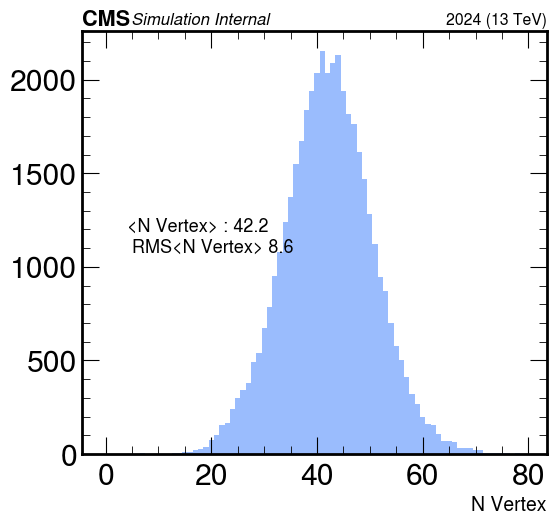

In [173]:
_=plt.hist(dataStore['Nvtx'],np.arange(-0.5,80.0,1),alpha=0.6)
mu=np.average(dataStore['Nvtx'])
stdev=np.std(dataStore['Nvtx'])
plt.text(4,max(_[0])*0.5,f"<N Vertex> : {mu:.1f}\n RMS<N Vertex> {stdev:.1f}",fontsize=13)
plt.xlabel('N Vertex',fontsize=14)
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
hep.cms.label('Internal',fontsize=12,data=False,year='2024')
if saveFig:
    plt.savefig(f'{prefix}/pu.png',bbox_inches='tight')

/tmp/ipykernel_2484471/2365137497.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  intNTT=np.array(dataStore['l1tEmuNTT'][gMask],dtype=int)


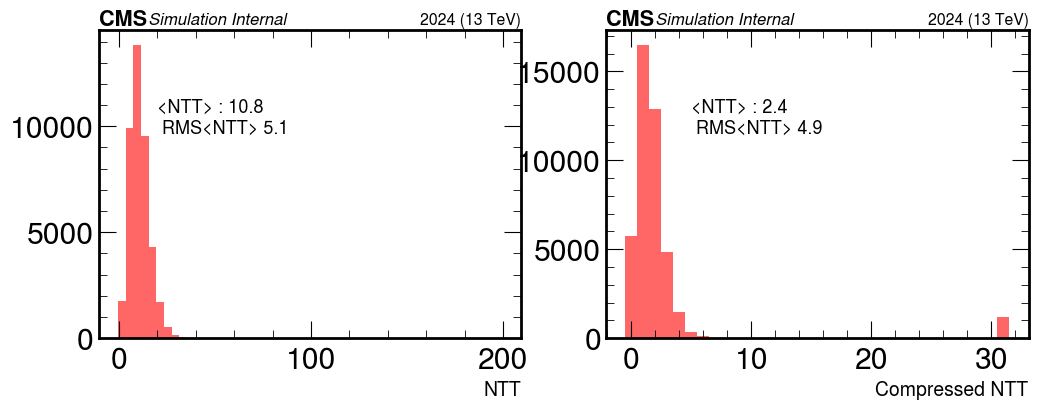

In [174]:
gMask=dataStore['l1tEmuNTT']>0
intNTT=np.array(dataStore['l1tEmuNTT'][gMask],dtype=int)

compressedNTT=dataStore['compressedNTT']

f,ax=plt.subplots(1,2,figsize=(12,4))

_=ax[0].hist(dataStore['l1tEmuNTT'][gMask],np.arange(-0.5,200.0,4),alpha=0.6,color='r')
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
mu=np.average(dataStore['l1tEmuNTT'][gMask])
stdev=np.std(dataStore['l1tEmuNTT'][gMask])
ax[0].text(20,max(_[0])*0.7,f"<NTT> : {mu:.1f}\n RMS<NTT> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('NTT',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])

_=ax[1].hist(compressedNTT,np.arange(-0.5,32.0,1),alpha=0.6,color='r')
mu=np.average(compressedNTT)
stdev=np.std(compressedNTT)
ax[1].text(5,max(_[0])*0.7,f"<NTT> : {mu:.1f}\n RMS<NTT> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('Compressed NTT',fontsize=14)
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[1])
if saveFig:
    plt.savefig(f'{prefix}/compressedNTT.png',bbox_inches='tight')
# plt.semilogy()

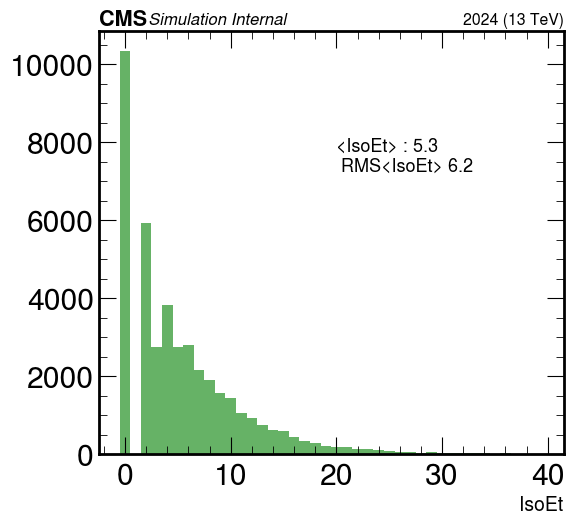

In [175]:
_=plt.hist(dataStore['l1tEmuIsoEt'],np.arange(-0.5,40.0,1),alpha=0.6,color='g')
mu=np.average(dataStore['l1tEmuIsoEt'])
stdev=np.std(dataStore['l1tEmuIsoEt'])
plt.text(20,max(_[0])*0.7,f"<IsoEt> : {mu:.1f}\n RMS<IsoEt> {stdev:.1f}",fontsize=13)
plt.xlabel('IsoEt',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024')
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/IsoEt.png',bbox_inches='tight')

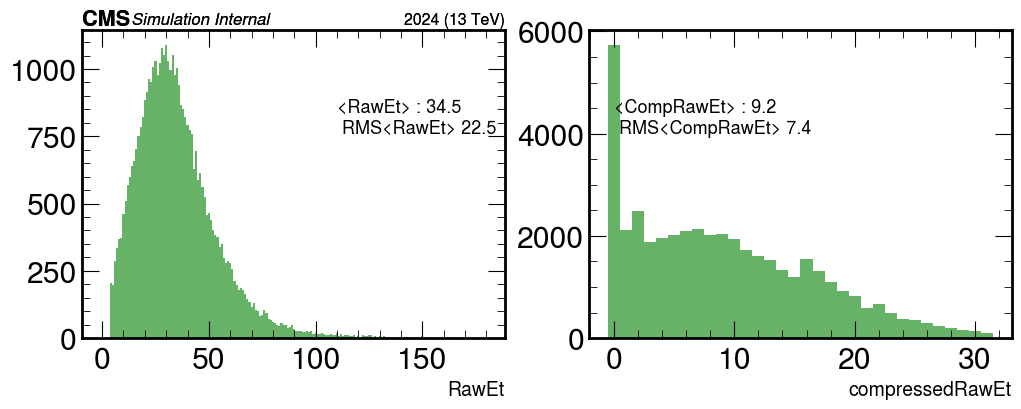

In [176]:
f,ax=plt.subplots(1,2,figsize=(12,4))

_=ax[0].hist(dataStore['l1tEmuRawEt'],np.arange(-0.5,180.0,1),alpha=0.6,color='g')
mu=np.average(dataStore['l1tEmuRawEt'])
stdev=np.std(dataStore['l1tEmuRawEt'])
ax[0].text(110,max(_[0])*0.7,f"<RawEt> : {mu:.1f}\n RMS<RawEt> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('RawEt',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])


_=ax[1].hist(dataStore['compressedRawEt'],np.arange(-0.5,32.0,1),alpha=0.6,color='g')
mu=np.average(dataStore['compressedRawEt'])
stdev=np.std(dataStore['compressedRawEt'])
ax[1].text(0,max(_[0])*0.7,f"<CompRawEt> : {mu:.1f}\n RMS<CompRawEt> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('compressedRawEt',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/compressedRawEt.png',bbox_inches='tight')

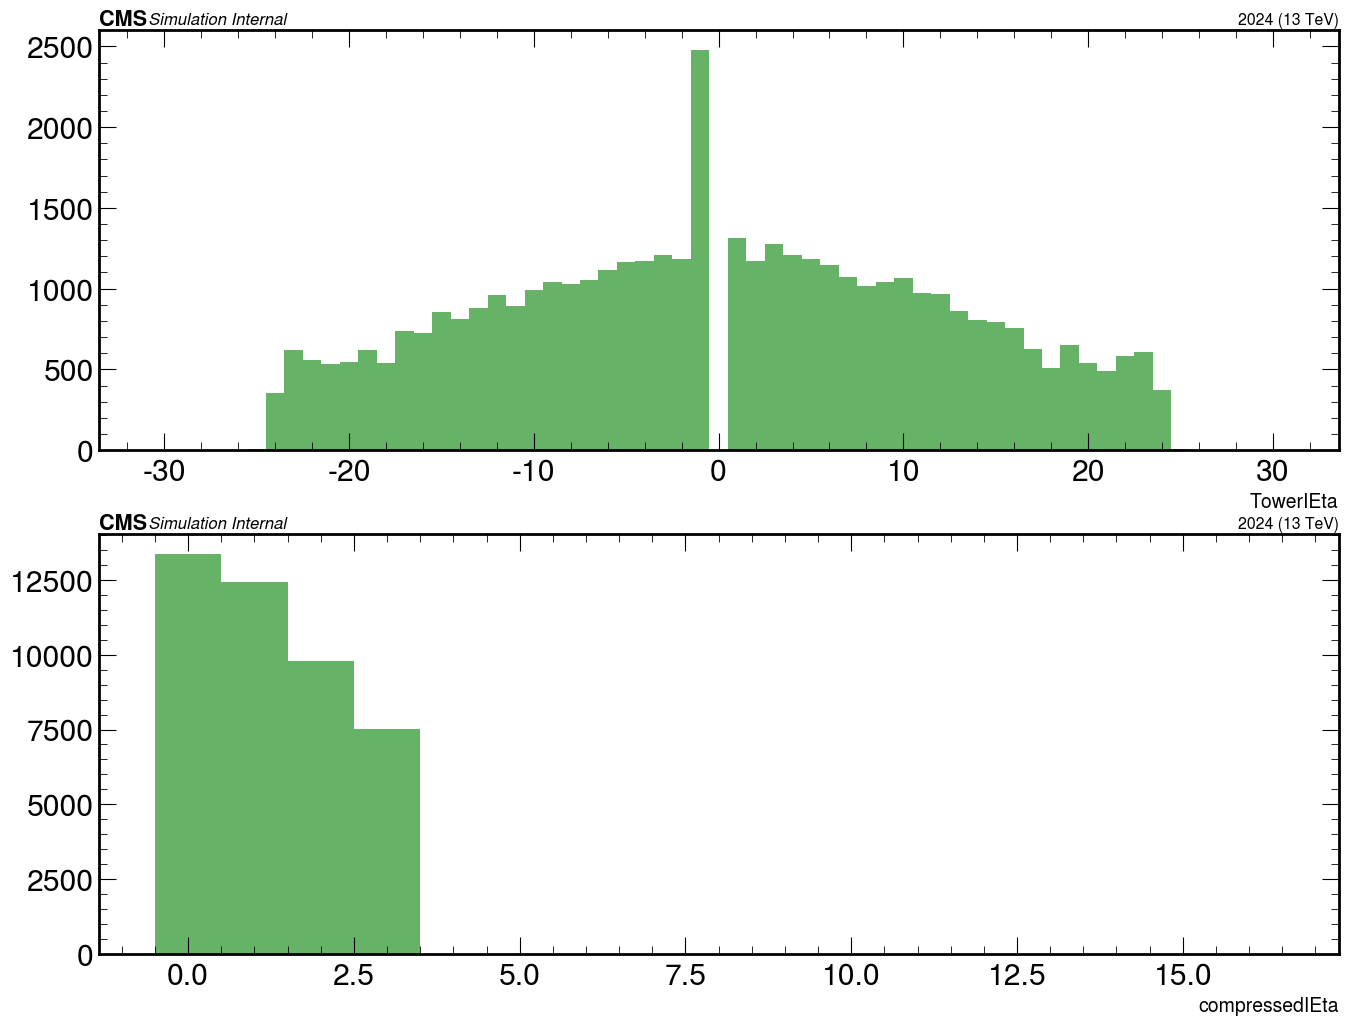

In [177]:
f,ax=plt.subplots(2,1,figsize=(16,12))
_=ax[0].hist(dataStore['l1tEmuTowerIEta'],np.arange(-30.5,31.0,1),alpha=0.6,color='g')
# mu=np.average(dataStore['l1tEmuEta'])
# stdev=np.std(dataStore['l1tEmuEta'])
# plt.text(110,max(_[0])*0.7,f"<l1tEmuEta> : {mu:.1f}\n RMS<l1tEmuEta> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('TowerIEta',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])

_=ax[1].hist(dataStore['compressedIEta'],np.arange(-0.5,17.0,1),alpha=0.6,color='g')
# mu=np.average(dataStore['l1tEmuEta'])
# stdev=np.std(dataStore['l1tEmuEta'])
# plt.text(110,max(_[0])*0.7,f"<l1tEmuEta> : {mu:.1f}\n RMS<l1tEmuEta> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('compressedIEta',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[1])
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/compressedIEta.png',bbox_inches='tight')

In [178]:
ieta=dataStore['compressedIEta']
iet =dataStore['compressedRawEt']
intt=dataStore['compressedNTT']

lut_index = ieta<<10 | iet <<5 | intt

In [179]:
isolationFname='LUT_0p7_12_26.txt'

with open(isolationFname) as f:
    txt=f.readlines()

idx=0
isoLUT=[]
for l in txt:
    if len(l) <2 : continue
    if l.startswith('#') : continue
    l=l.split('#')[0].strip().split()
    index=int(l[0])
    if index!=idx:
        print(f"LUT not proper ! for expected index {idx} , the value obtained is {index}")
        raise ValueError
    isoLUT.append(int(l[1]))
    idx+=1
isoLUT=np.array(isoLUT)        

In [180]:
isolation_thr = isoLUT[lut_index]

In [181]:
isolation_bit = (dataStore['l1tEmuIsoEt'] < isolation_thr) & ( dataStore.l1tEmuIsoEt >-1)

In [182]:
np.sum(isolation_bit)/len(dataStore['l1tEmuIsoEt'])

np.float64(0.7352545361733723)

In [183]:
np.unique(dataStore.l1tEmuIso,return_counts=True)

<Array [[-1, 0, 1], [1195, 18320, 23583]] type='2 * var * int64'>

In [184]:
# loose_isoMask = (dataStore.l1tEmuIso ==1 ) | (dataStore.l1tEmuIso ==3 )
# tight_isoMask = (dataStore.l1tEmuIso ==1 ) | (dataStore.l1tEmuIso ==3 )

loose_isoMask = (dataStore.l1tIso ==1 ) | (dataStore.l1tIso ==3 )
tight_isoMask = (dataStore.l1tIso ==1 ) | (dataStore.l1tIso ==3 )

In [185]:
np.sum(loose_isoMask)

np.int64(11819)

In [186]:
BINS=np.arange(0.0,100.1,1.0)-0.5

In [187]:
# dataStore['dR']= np.sqrt( 
#                          ( dataStore['eleProbeEta'] - dataStore['eleTagEta'] )**2 + 
#                          ( dataStore['eleProbePhi'] - dataStore['eleTagPhi'] )**2 
#                         ) 

preselection_mask = np.abs(dataStore['tauEta']) < 2.5
# preselection_mask = np.logical_and( preselection_mask , dataStore['dR'] > 0.6 )
# preselection_mask = np.logical_and( preselection_mask , dataStore['isProbeLoose'] > 0.5 ) 
print("Preliminary selection : ",np.sum(preselection_mask)," / ",len(preselection_mask))


Preliminary selection :  43098  /  43098


In [188]:
count_all,binx_=np.histogram(dataStore['tauPt'][preselection_mask],bins=BINS)

COUNT_ALL=count_all
BIN_X=0.5*(BINS[1:]+BINS[:-1])

In [189]:
efficiencyMap={}

for et in range(81):
    effDict={}
    eff_name=f"SingleEG_{et}"
    print(f"\rProcessing {eff_name}   !",end="")
    triggerSeedMask = dataStore['l1tEmuPt'] >= et
    triggerSeedMask = np.logical_and(triggerSeedMask,preselection_mask)
    
    count_trig,binx_= np.histogram(dataStore['tauPt'][triggerSeedMask],bins=BINS)
    effDict['pass'] = [int(i) for i in count_trig ]
    effDict['all']  = COUNT_ALL
    eff=count_trig/(COUNT_ALL+1e-9)
    effDict['efficiency']  = eff
    effDict['bin']  = BINS
    effDict['bin_center'] = BIN_X
    
    efficiencyMap[eff_name] = effDict
    
    

Processing SingleEG_80   !

In [190]:
unpackedIsoefficiencyMap={}

for et in range(81):
    effDict={}
    eff_name=f"SingleEG_{et}"
    print(f"\rProcessing {eff_name}   !",end="")
    triggerSeedMask = dataStore['l1tEmuPt'] >= et
    triggerSeedMask = np.logical_and(triggerSeedMask,preselection_mask)
    triggerSeedMask = np.logical_and(triggerSeedMask,loose_isoMask)
    
    count_trig,binx_= np.histogram(dataStore['tauPt'][triggerSeedMask],bins=BINS)
    effDict['pass'] = [int(i) for i in count_trig ]
    effDict['all']  = COUNT_ALL
    eff=count_trig/(COUNT_ALL+1e-9)
    effDict['efficiency']  = eff
    effDict['bin']  = BINS
    effDict['bin_center'] = BIN_X
    
    unpackedIsoefficiencyMap[eff_name] = effDict
    
    

Processing SingleEG_80   !

In [191]:
isoefficiencyMap={}

for et in range(81):
    effDict={}
    eff_name=f"SingleEG_{et}"
    print(f"\rProcessing {eff_name}   !",end="")
    triggerSeedMask = dataStore['l1tEmuPt'] >= et
    triggerSeedMask = np.logical_and(triggerSeedMask,preselection_mask)
    triggerSeedMask = np.logical_and(triggerSeedMask,isolation_bit)
    
    count_trig,binx_= np.histogram(dataStore['tauPt'][triggerSeedMask],bins=BINS)
    effDict['pass'] = [int(i) for i in count_trig ]
    effDict['all']  = COUNT_ALL
    eff=count_trig/(COUNT_ALL+1e-9)
    effDict['efficiency']  = eff
    effDict['bin']  = BINS
    effDict['bin_center'] = BIN_X
    
    isoefficiencyMap[eff_name] = effDict
    
    

Processing SingleEG_80   !

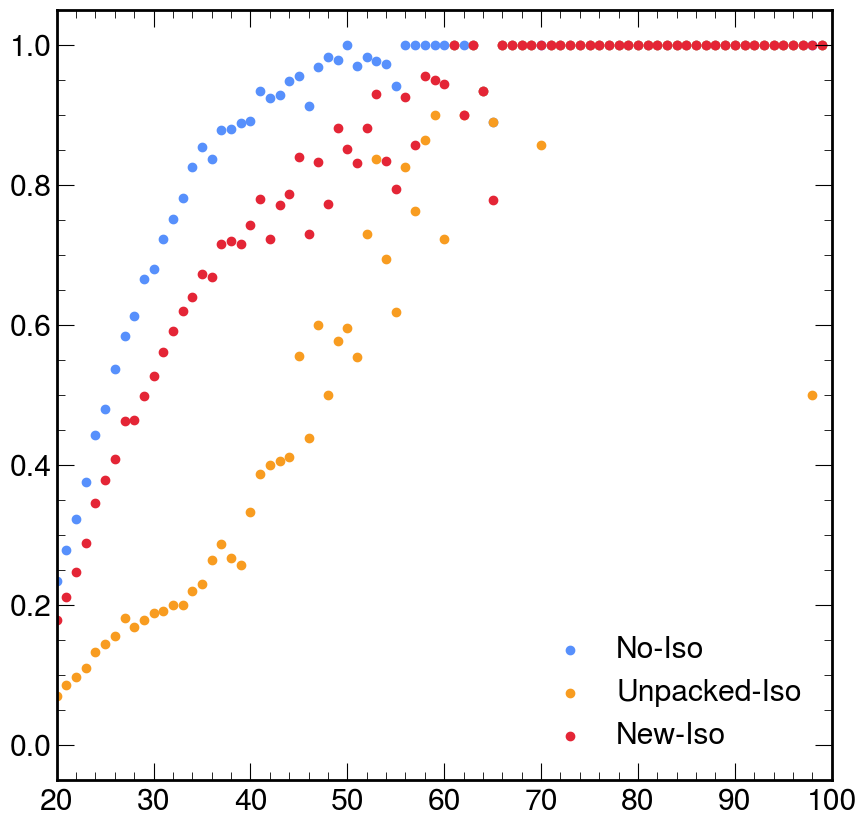

In [192]:
et=26
eff_name=f"SingleEG_{et}"
hep.style.use("CMS")
plt.scatter(efficiencyMap[eff_name]['bin_center'],efficiencyMap[eff_name]['efficiency'],label='No-Iso')
plt.scatter(unpackedIsoefficiencyMap[eff_name]['bin_center'],unpackedIsoefficiencyMap[eff_name]['efficiency'],label='Unpacked-Iso')
plt.scatter(isoefficiencyMap[eff_name]['bin_center'],isoefficiencyMap[eff_name]['efficiency'],label='New-Iso')
plt.xlim(20,100)
plt.legend()